# Forecasting Revenue at Risk with Linear Regression

This notebook estimates how much revenue is at risk because of late deliveries and uses a linear regression model to forecast that risk forward by 12 months. It pulls order and shipping data from the database, aggregates it by month, fits a trend line to historical at-risk revenue, and projects that trend into the future.

## Setup

The cell below imports the required libraries, connects to the SQLite database, and defines a helper function called `run_query_to_df` that runs a SQL query and returns the results as a pandas DataFrame.

In [31]:
# Import necessary libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'svg'

print("Libraries imported successfully!")

# Connect to the SQLite database
conn = sqlite3.connect("inventory.db")

# Create a cursor object to interact with the database
cursor = conn.cursor()

# Function to run a SQL query and return the results as a DataFrame
def run_query_to_df(cursor, query):
    cursor.execute(query)
    rows = cursor.fetchall()
    
    # Get column names from cursor
    columns = []
    for col in cursor.description:
        columns.append(col[0])

    # Convert to DataFrame
    df = pd.DataFrame(rows, columns = columns)

    return df

Libraries imported successfully!


## Total Revenue and Revenue at Risk

This query calculates two things across all orders: total revenue (product price times quantity) and the portion of that revenue tied to orders flagged as at risk of a late delivery. A percentage column is added in Python to show what share of total revenue is at risk. This percentage is carried forward and used as the estimated late delivery rate when forecasting future risk.

In [32]:
query = """
SELECT
    SUM(p.product_price * oi.quantity) AS total_revenue,
    SUM(CASE WHEN s.late_delivery_risk = 1
        THEN p.product_price * oi.quantity ELSE 0 END) AS revenue_at_risk
FROM orders o
JOIN order_items oi ON o.id = oi.order_id
JOIN shipping s    ON o.id = s.order_id
JOIN products p    ON oi.product_id = p.id
"""

# Call the function to run the query and display results
result = run_query_to_df(cursor, query)
result['pct_at_risk'] = round(result['revenue_at_risk'] / result['total_revenue'] * 100, 2)
result

,total_revenue,revenue_at_risk,pct_at_risk
0,3.424827e+07,1.875148e+07,54.75


## Monthly Revenue Breakdown

This query pulls order-level revenue and the late delivery risk flag for every order. In Python the order date is parsed into a month period, and the data is grouped by month to get total revenue and total at-risk revenue per month. A sequential month index column is also added so the data can be used as the numeric input for linear regression.

In [33]:
query = """
SELECT
    o.order_date,
    p.product_price * oi.quantity AS order_revenue,
    s.late_delivery_risk
FROM orders o
JOIN order_items oi ON o.id = oi.order_id
JOIN shipping s    ON o.id = s.order_id
JOIN products p    ON oi.product_id = p.id
"""

data = run_query_to_df(cursor, query)
data['order_date'] = pd.to_datetime(data['order_date'])
data['order_month'] = data['order_date'].dt.to_period('M')
data['at_risk_revenue'] = data['order_revenue'] * data['late_delivery_risk']

monthly = data.groupby('order_month').agg(
    total_revenue=('order_revenue', 'sum'),
    revenue_at_risk=('at_risk_revenue', 'sum')
).reset_index()

monthly['month_index'] = range(len(monthly))

monthly.head(10)

,order_month,total_revenue,revenue_at_risk,month_index
0,2015-01,1.051590e+06,570920.860118,0
1,2015-02,9.270099e+05,508672.909679,1
2,2015-03,1.051254e+06,571798.370231,2
3,2015-04,1.014463e+06,547556.390495,3
4,2015-05,1.050478e+06,580294.990281,4
5,2015-06,1.024006e+06,554935.860256,5
6,2015-07,1.038081e+06,578889.800716,6
7,2015-08,1.029495e+06,579159.510933,7
8,2015-09,1.018339e+06,577902.390885,8
9,2015-10,1.049154e+06,571324.380470,9


## Fitting the Regression and Forecasting

A simple linear regression model is fit with the month index as the input and total monthly revenue as the output. The model learns the overall trend in revenue over time. It is then used to predict revenue for the next 12 months, and the estimated late delivery rate from the first query is applied to those predictions to get the forecasted revenue at risk. The R-squared value printed below shows how well the linear trend fits the historical monthly data.

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

late_rate = result.iloc[0]['pct_at_risk'] / 100
forecast_months = 12

X = monthly[['month_index']]
y = monthly['total_revenue']

model = LinearRegression()
model.fit(X, y)

future_X = np.arange(len(monthly), len(monthly) + forecast_months).reshape(-1, 1)
future_revenue = model.predict(future_X)
future_at_risk = future_revenue * late_rate

print(f"Late delivery rate: {late_rate * 100:.1f}%")
print(f"R²: {r2_score(y, model.predict(X)):.2f}")
print(f"Projected revenue at risk (next {forecast_months} months): ${future_at_risk.sum():,.0f}")

Late delivery rate: 54.8%
R²: 0.23
Projected revenue at risk (next 12 months): $7,112,124


/usr/local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Chart: Historical Revenue at Risk and Forecast

The chart plots actual monthly revenue at risk as a solid blue line and overlays a dashed orange line showing the fitted trend extended through the 12-month forecast period. The vertical dotted gray line marks where the historical data ends and the forecast begins. This makes it easy to see the direction of the trend and get a rough sense of how much revenue could be at risk over the next year if current delivery patterns continue.

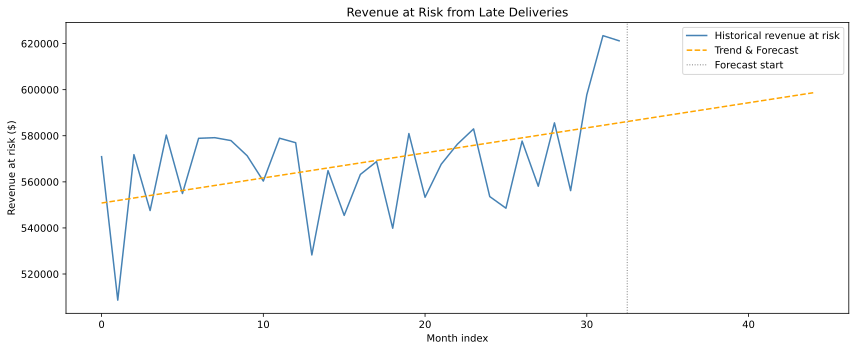

In [35]:
# Build one continuous trendline: fitted over history + forecast extension
fitted_at_risk = model.predict(monthly[['month_index']]) * late_rate
all_X            = np.concatenate([monthly['month_index'].values, future_X.flatten()])
all_trend_at_risk = np.concatenate([fitted_at_risk, future_at_risk])

plt.figure(figsize=(12, 5))
plt.plot(monthly['month_index'], monthly['revenue_at_risk'],
         color='steelblue', label='Historical revenue at risk')
plt.plot(all_X, all_trend_at_risk, '--', color='orange',
         label='Trend & Forecast')
plt.axvline(x=monthly['month_index'].iloc[-1] + 0.5,
            color='gray', linestyle=':', linewidth=1, label='Forecast start')
plt.title('Revenue at Risk from Late Deliveries')
plt.xlabel('Month index')
plt.ylabel('Revenue at risk ($)')
plt.legend()
plt.tight_layout()
plt.show()